# README
Project title: Churn predictor  
Project Description:  
* We are using a dataset from Kaggle that will help us determine which users will most likely drop the telecommunication service. The following dataset can be downloaded [here](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
* Our current form of machine learning colaboration is from Google colab
* Our goal is to follow and apply the Cross-Industry Standard Process for Data Mining (CRISP-DM) to our dataset and understand the process.

Setup Instruction:
1. Ensure that you have downloaded the correct dataset which was provided
2. upload it to your google drive (<font color = 'red'>**Notice:**</font> Placing the dataset in the correct location prevents any potential issues. To ensure no future frustration place the contents together in the same folder)
3. Create or open a Google Colab
4. Click the button that says **Run all**

Environment Requirement:
* Google Colab
* Python 3
* Libraries
  - OS
  - Pandas
  - NumPy
  - Sklearn
  - Matplotlib

Expected output:
* Numbers regarding the program feature analysis and feature engineering at this stage.

# Data Loading
import the necessary libraries and mount the csv file in notebook as well as uploading the dataset

In [ ]:
#Import the libraries
import os
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score,accuracy_score,precision_score,recall_score,confusion_matrix
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

#Mount the Google drive
drive.mount('/content/drive/')

#Locate and load dataset
target_file = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
search_root = '/content/drive/MyDrive'

file_path = None

for root, dirs, files in os.walk(search_root):
    if target_file in files:
        file_path = os.path.join(root, target_file)
        break

if file_path is None:
  raise FileNotFoundError(
      f"{target_file} was not found in the specified directory structure. "
      "Please upload the CSV file to your Google Drive and run this cell again"
  )

df = pd.read_csv(file_path)
print('Dataset loaded successfully')
#Expected output -
#Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
#Dataset loaded successfully

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Dataset loaded successfully


#Feature Analysis (Assignment #3)



gender
----------------
gender
Male      3555
Female    3488
Name: count, dtype: int64




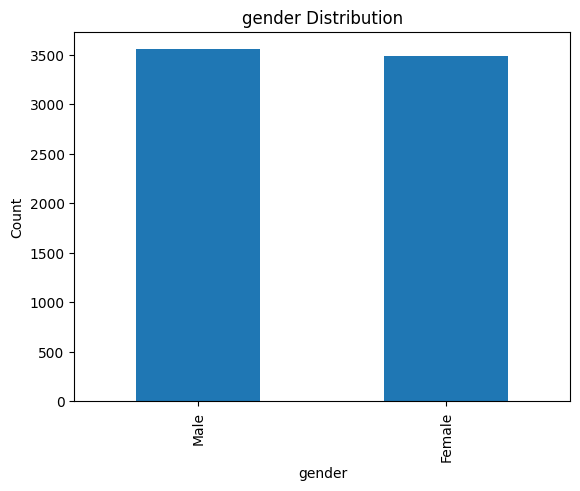


SeniorCitizen
----------------
SeniorCitizen
No     5901
Yes    1142
Name: count, dtype: int64




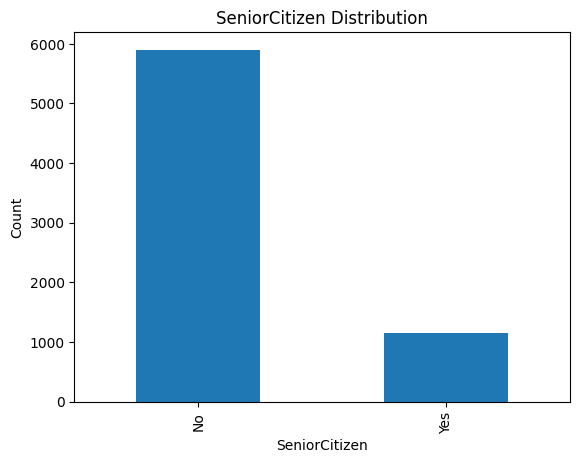


Partner
----------------
Partner
No     3641
Yes    3402
Name: count, dtype: int64




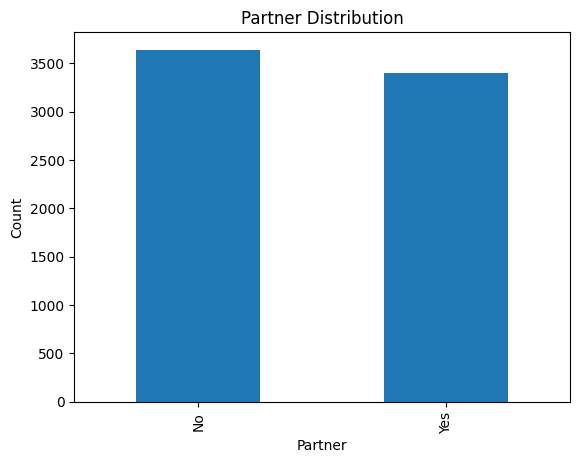


Dependents
----------------
Dependents
No     4933
Yes    2110
Name: count, dtype: int64




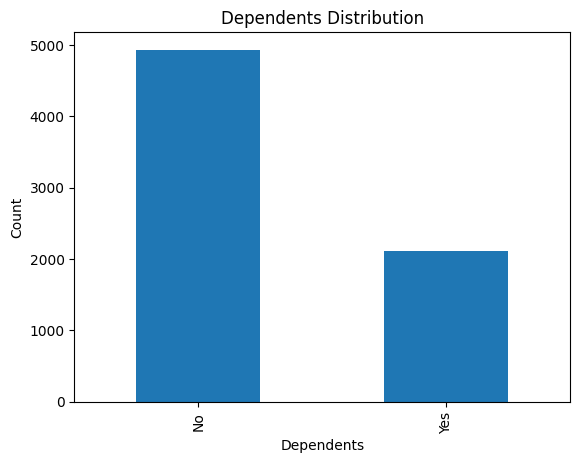


PhoneService
----------------
PhoneService
Yes    6361
No      682
Name: count, dtype: int64




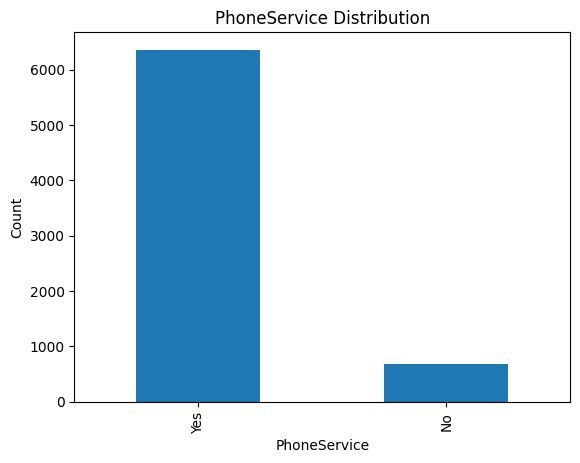


MultipleLines
----------------
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64




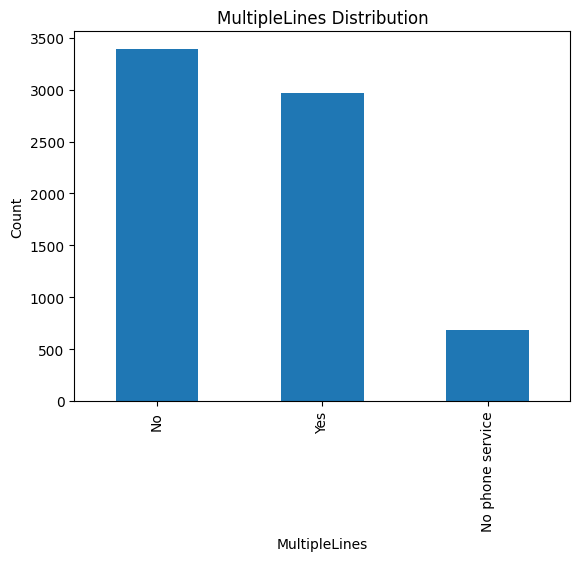


InternetService
----------------
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64




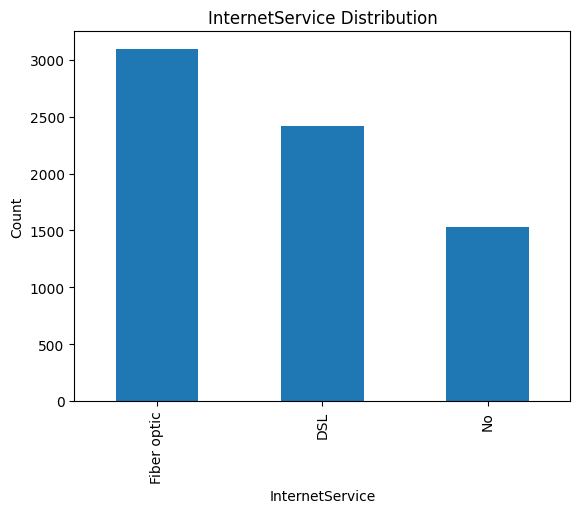


OnlineSecurity
----------------
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64




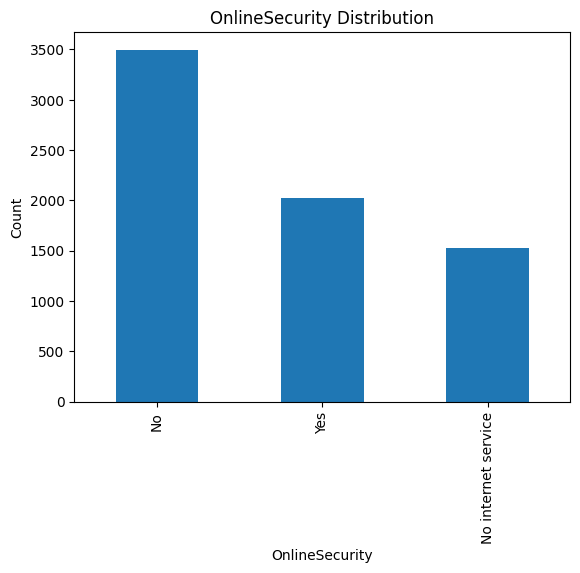


OnlineBackup
----------------
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64




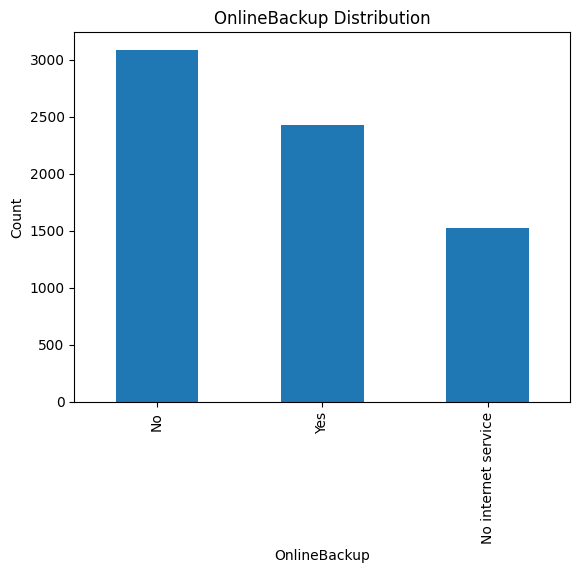


DeviceProtection
----------------
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64




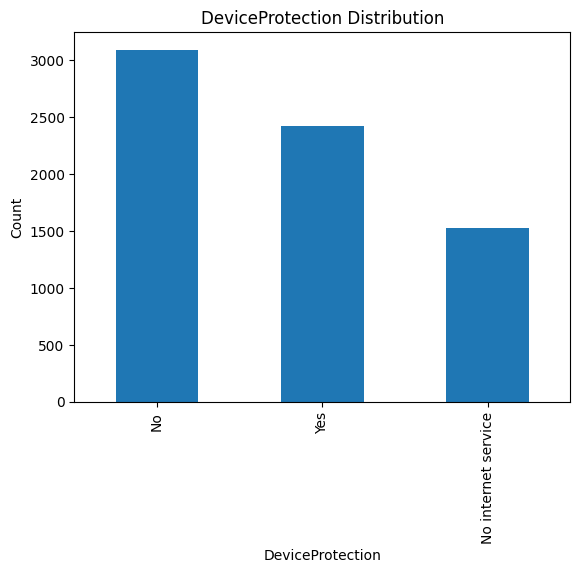


TechSupport
----------------
TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64




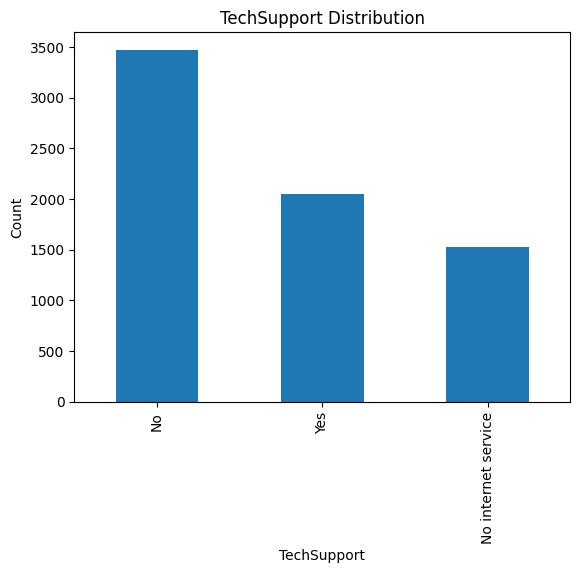


StreamingTV
----------------
StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64




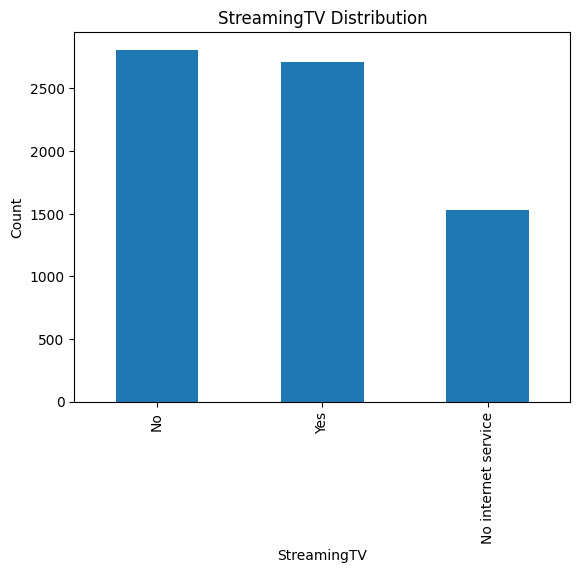


StreamingMovies
----------------
StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64




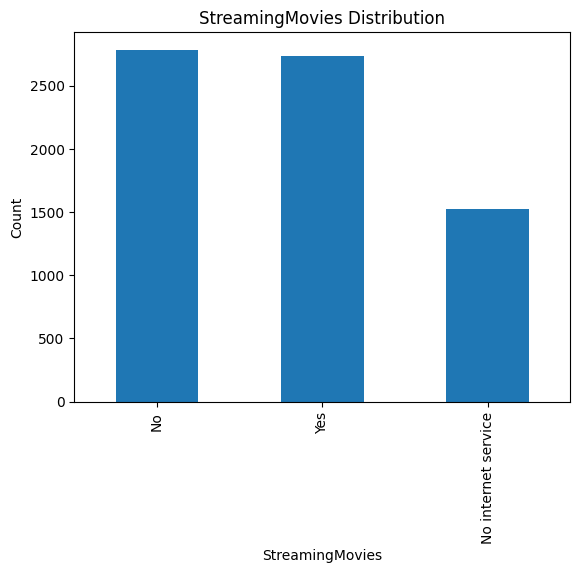


Contract
----------------
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64




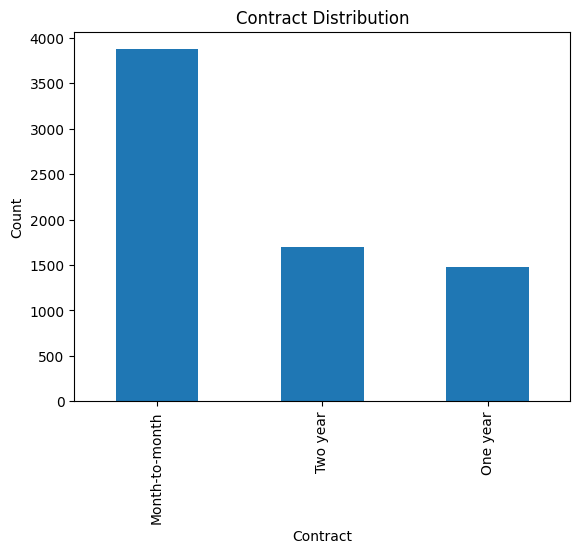


PaperlessBilling
----------------
PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64




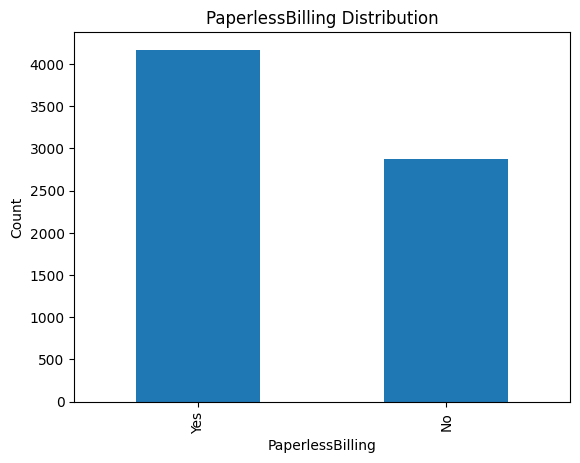


PaymentMethod
----------------
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64




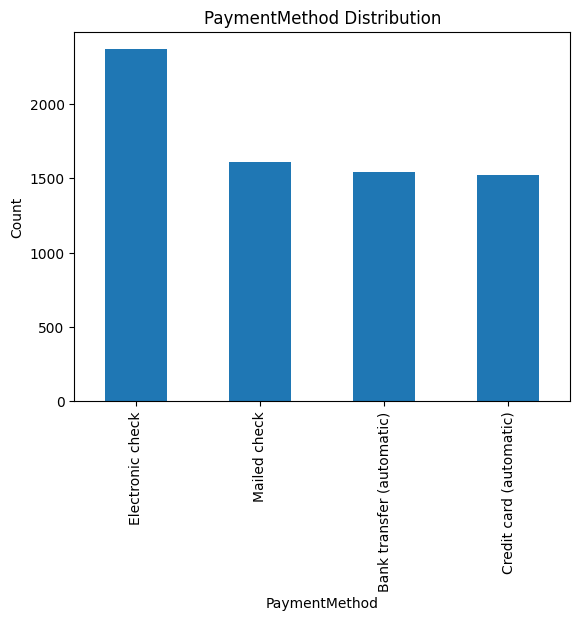


Churn
----------------
Churn
No     5174
Yes    1869
Name: count, dtype: int64




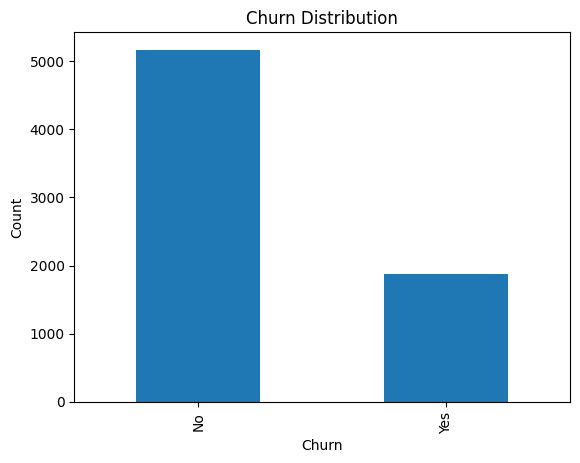


tenure
---------------
Mean: 32.421786120591584
Median: 29.0
Mode: 1
Midrange: 36.5

MonthlyCharges
---------------
Mean: 64.79820819112628
Median: 70.35
Mode: 20.05
Midrange: 68.5

TotalCharges
---------------
Mean: 2283.300440841866
Median: 1397.475
Mode: 20.2
Midrange: 4351.799999999999
-----------------------

tenure
---------------
Min: 1
Q1: 9.0
Q2 (Median): 29.0
Q3: 55.0
Max: 72
Range: 71
IQR: 46.0

MonthlyCharges
---------------
Min: 18.25
Q1: 35.5875
Q2 (Median): 70.35
Q3: 89.8625
Max: 118.75
Range: 100.5
IQR: 54.275

TotalCharges
---------------
Min: 18.8
Q1: 401.45
Q2 (Median): 1397.475
Q3: 3794.7375
Max: 8684.8
Range: 8666.0
IQR: 3393.2875000000004


-----------------------
Variance:
tenure            6.024698e+02
MonthlyCharges    9.051658e+02
TotalCharges      5.138252e+06
dtype: float64
-----------------------


-----------------------
Standard Deviation:
tenure              24.545260
MonthlyCharges      30.085974
TotalCharges      2266.771362
dtype: float64
-----------

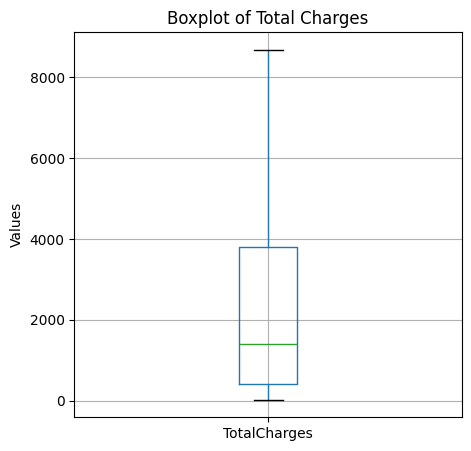

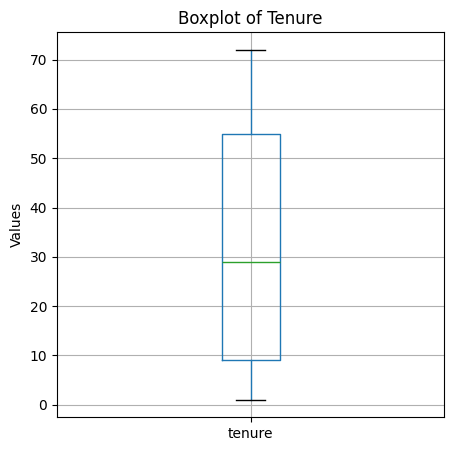

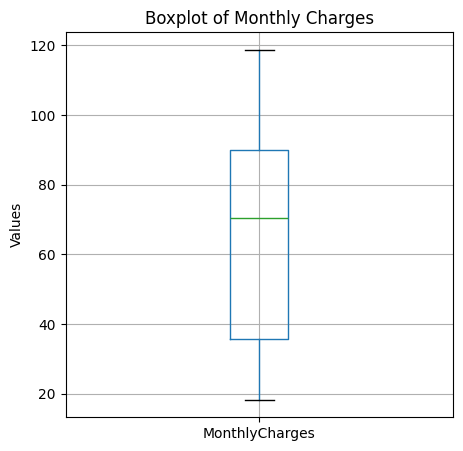


Class Imbalance
--------------------------
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [ ]:

df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
for col in ['gender','SeniorCitizen','Partner','Dependents',
            'PhoneService','MultipleLines','InternetService',
            'OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies',
            'Contract','PaperlessBilling','PaymentMethod','Churn']:

    counts = df[col].value_counts()

    print(f"\n{col}")
    print("----------------")
    print(counts)
    print("\n")
    counts.plot(kind='bar')
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')
df = df.dropna()

for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    print(f"\n{col}")
    print("---------------")
    print(f"Mean: {df[col].mean()}")
    print(f"Median: {df[col].median()}")
    print(f"Mode: {df[col].mode()[0]}")
    print(f"Midrange: {(df[col].max() + df[col].min()) / 2}")

print("-----------------------")
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    Q1 = df[col].quantile(0.25)
    Q2 = df[col].quantile(0.50)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    col_min = df[col].min()
    col_max = df[col].max()
    col_range = col_max - col_min

    print(f"\n{col}")
    print("---------------")
    print(f"Min: {col_min}")
    print(f"Q1: {Q1}")
    print(f"Q2 (Median): {Q2}")
    print(f"Q3: {Q3}")
    print(f"Max: {col_max}")
    print(f"Range: {col_range}")
    print(f"IQR: {IQR}")

print("\n")
print("-----------------------")
print("Variance:")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].var())
print("-----------------------")
print("\n")

print("-----------------------")
print("Standard Deviation:")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].std())
print("-----------------------")
print("\n")

plt.figure(figsize=(5,5))
df.boxplot(column='TotalCharges')
plt.title('Boxplot of Total Charges')
plt.ylabel('Values')
plt.show()

plt.figure(figsize=(5,5))
df.boxplot(column='tenure')
plt.title('Boxplot of Tenure')
plt.ylabel('Values')
plt.show()

plt.figure(figsize=(5,5))
df.boxplot(column='MonthlyCharges')
plt.title('Boxplot of Monthly Charges')
plt.ylabel('Values')
plt.show()


print(f"\nClass Imbalance")
print("--------------------------")
print(df['Churn'].value_counts(normalize=True) * 100)




Skewness
--------------------------


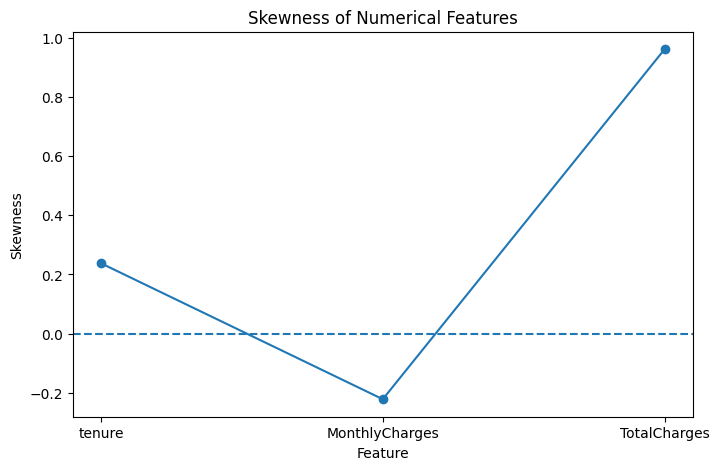

In [ ]:
print("\nSkewness")
print("--------------------------")

skewness_values = df[['tenure', 'MonthlyCharges', 'TotalCharges']].skew()

skewness_table = pd.DataFrame({
    'Feature': skewness_values.index,
    'Skewness': skewness_values.values
})

def explain_skew(value):
    if value > 0.5:
        return "Right-skewed"
    elif value < -0.5:
        return "Left-skewed"
    elif value > 0:
        return "Slightly right-skewed"
    elif value < 0:
        return "Slightly left-skewed"
    else:
        return "Fairly symmetric"

skewness_table['Interpretation'] = skewness_table['Skewness'].apply(explain_skew)

plt.figure(figsize=(8,5))

plt.plot(
    skewness_table['Feature'],
    skewness_table['Skewness'],
    marker='o'
)

plt.title('Skewness of Numerical Features')
plt.xlabel('Feature')
plt.ylabel('Skewness')

plt.axhline(y=0, linestyle='--')  # Reference line for symmetry

plt.show()

In [ ]:
print("\nCorrelation With Churn")
print("--------------------------")

df_corr = df.copy()

df_corr['Churn_Numeric'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

correlation_values = df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Numeric']].corr()['Churn_Numeric'].drop('Churn_Numeric')

correlation_table = pd.DataFrame({
    'Feature': correlation_values.index,
    'Correlation With Churn': correlation_values.values
})

def explain_corr(value):
    if value > 0.5:
        return "Strong positive relationship"
    elif value > 0.2:
        return "Weak positive relationship"
    elif value > 0:
        return "Very weak positive relationship"
    elif value < -0.5:
        return "Strong negative relationship"
    elif value < -0.2:
        return "Weak negative relationship"
    elif value < 0:
        return "Very weak negative relationship"
    else:
        return "No relationship"

correlation_table['Interpretation'] = correlation_table['Correlation With Churn'].apply(explain_corr)

print(correlation_table)


Correlation With Churn
--------------------------
          Feature  Correlation With Churn                   Interpretation
0          tenure               -0.354049       Weak negative relationship
1  MonthlyCharges                0.192858  Very weak positive relationship
2    TotalCharges               -0.199484  Very weak negative relationship


In [ ]:
print("\Caetgorical Features Percentages With Churn")
print("---------------------------------------------")


categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

print("\nChurn Percentage Analysis")
print("--------------------------")
for col in categorical_cols:
    print(f"\n{col}")
    print("--------------------------")
    churn_table = pd.crosstab(
        df[col],
        df['Churn'],
        normalize='index'
    ) * 100
    churn_table.columns = ['No Churn', 'Churn']
    churn_table.index.name = None
    print(churn_table.round(2))

\Caetgorical Features Percentages With Churn
---------------------------------------------

Churn Percentage Analysis
--------------------------

gender
--------------------------
        No Churn  Churn
Female     73.04  26.96
Male       73.80  26.20

SeniorCitizen
--------------------------
     No Churn  Churn
No      76.35  23.65
Yes     58.32  41.68

Partner
--------------------------
     No Churn  Churn
No      67.02  32.98
Yes     80.28  19.72

Dependents
--------------------------
     No Churn  Churn
No      68.72  31.28
Yes     84.47  15.53

PhoneService
--------------------------
     No Churn  Churn
No      75.00  25.00
Yes     73.25  26.75

MultipleLines
--------------------------
                  No Churn  Churn
No                   74.92  25.08
No phone service     75.00  25.00
Yes                  71.35  28.65

InternetService
--------------------------
             No Churn  Churn
DSL             81.00  19.00
Fiber optic     58.11  41.89
No              92.57   7.43


<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipykernel_7011/3147689580.py:1: SyntaxWarning: invalid escape sequence '\C'
  print("\Caetgorical Features Percentages With Churn")


                     No Churn  Churn
No                      58.22  41.78
No internet service     92.57   7.43
Yes                     85.36  14.64

OnlineBackup
--------------------------
                     No Churn  Churn
No                      60.06  39.94
No internet service     92.57   7.43
Yes                     78.43  21.57

DeviceProtection
--------------------------
                     No Churn  Churn
No                      60.86  39.14
No internet service     92.57   7.43
Yes                     77.46  22.54

TechSupport
--------------------------
                     No Churn  Churn
No                      58.35  41.65
No internet service     92.57   7.43
Yes                     84.80  15.20

StreamingTV
--------------------------
                     No Churn  Churn
No                      66.46  33.54
No internet service     92.57   7.43
Yes                     69.89  30.11

StreamingMovies
--------------------------
                     No Churn  Churn
No           

[link text](https://)# New Section

# Data Cleaning/Transformation

In [ ]:
print("\n Feature Engineering")
print(" ---------------------")
raw_df = df.copy()

#Changes Numerical Features from String values to floats/integers
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
df['tenure'] = pd.to_numeric(df['tenure'], errors='coerce')
print("\n String numbers changed to actual numbers")

#Drops rows with empty values - addresses issues with TotalCharges missing values
df = df.dropna()
print("\n Empty rows dropped")

#Encode Categorical Features

#Grouped encoding for features with the same results i.e Yes/No, etc.

#potential issue
#df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

yesNoCols = ['Partner','Dependents','PhoneService',
             'PaperlessBilling','Churn','SeniorCitizen']

for col in yesNoCols:
  df[col] = df[col].map({'No':0, 'Yes': 1})

internetServiceCols = ['StreamingMovies','StreamingTV','TechSupport',
                       'DeviceProtection','OnlineBackup','OnlineSecurity']

for col in internetServiceCols:
  df[col] = df[col].map({'No': 0, 'Yes': 1, 'No internet service': 2})

#Unique results that need to be encoded individually

df['MultipleLines'] = df['MultipleLines'].map({'No': 0, 'Yes': 1, 'No phone service': 2})
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
df['InternetService'] = df['InternetService'].map({'No': 0, 'DSL': 1, 'Fiber optic': 2})
df['Contract'] = df['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df['PaymentMethod'] = df['PaymentMethod'].map({'Bank transfer (automatic)': 0,
                                               'Mailed check': 1, 'Electronic check': 2,
                                               'Credit card (automatic)': 3})

print("\n Categorical Features Encoded")

#Normalize numerical data (MonthlyCharges, Tenure)

cols = ['MonthlyCharges', 'tenure', 'TotalCharges']

for col in cols:
  df[col] = (df[col] - df[col].mean()) / df[col].std()

print("\n Numerical data normalized")

#CHECK PAYMENTMETHOD

#Use SMOTE import from sklearn to fix class imabalance

#smote = SMOTE(random_state=42)

# Ex Line for resampling with smote: X_resampled, y_resampled = smote.fit_resample(X, y)

#print("\n Class imbalance solved")

#Double-check for redundancies/relationships that have little affect on churn

print(df)


 Feature Engineering
 ---------------------

 String numbers changed to actual numbers

 Empty rows dropped

 Categorical Features Encoded

 Numerical data normalized
      customerID  gender  SeniorCitizen  Partner  Dependents    tenure  \
0     7590-VHVEG       1              0        1           0 -1.280157   
1     5575-GNVDE       0              0        0           0  0.064298   
2     3668-QPYBK       0              0        0           0 -1.239416   
3     7795-CFOCW       0              0        0           0  0.512450   
4     9237-HQITU       1              0        0           0 -1.239416   
...          ...     ...            ...      ...         ...       ...   
7038  6840-RESVB       0              0        1           1 -0.343113   
7039  2234-XADUH       1              0        1           1  1.612459   
7040  4801-JZAZL       1              0        1           1 -0.872746   
7041  8361-LTMKD       0              1        1           0 -1.157934   
7042  3186-AJIEK  

# Feature Selection

In [ ]:
#TotalCharges should be dropped from final test, it's dependent on tenure, Monthly Charges
#Drop CustomerId because it has no effect on churn
df = df.drop('customerID', axis = 1)
df= df.drop('TotalCharges',axis = 1)
print("\n Useless/Redundant Features Dropped")


 Useless/Redundant Features Dropped


# Before/After Cleaning and Selection Comparison (Assignment #4)

Graphs showing Feature Engineering Before/After
 ---------------------------------------------------
Rows before: 7032
Rows after: 7032
Rows removed: 0


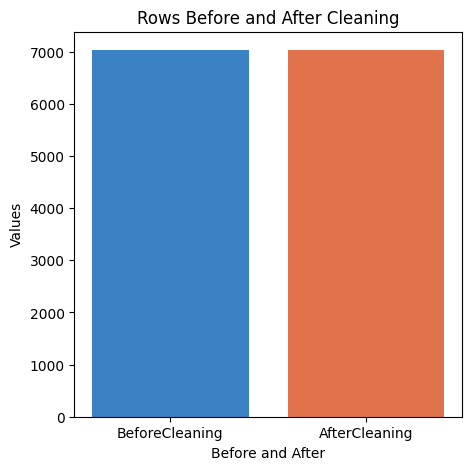

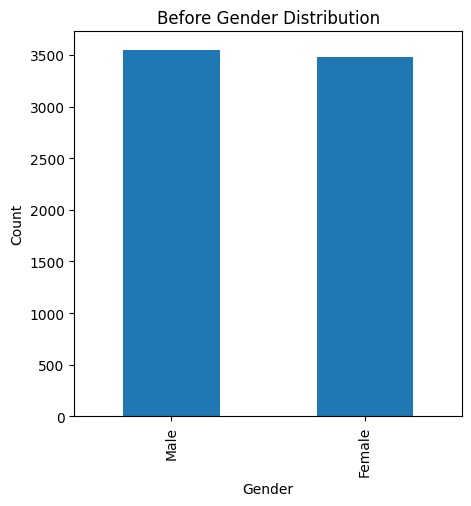

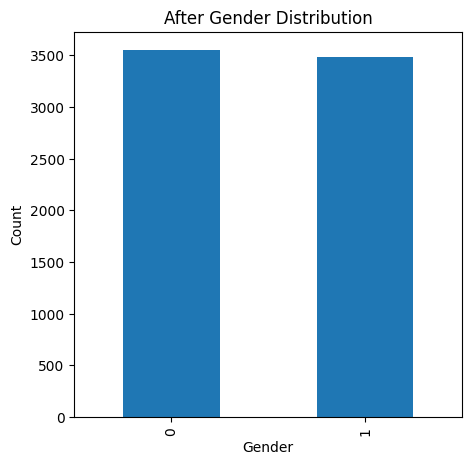

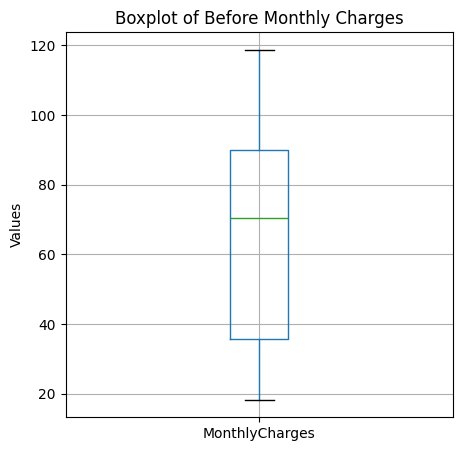

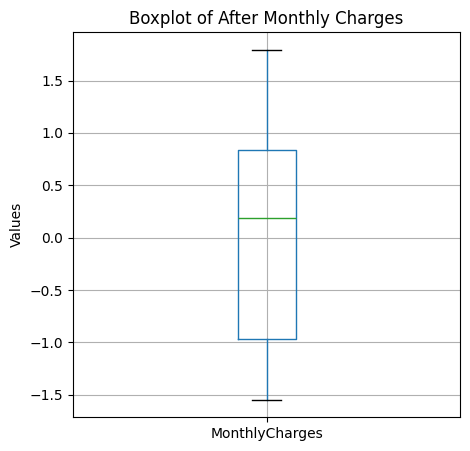

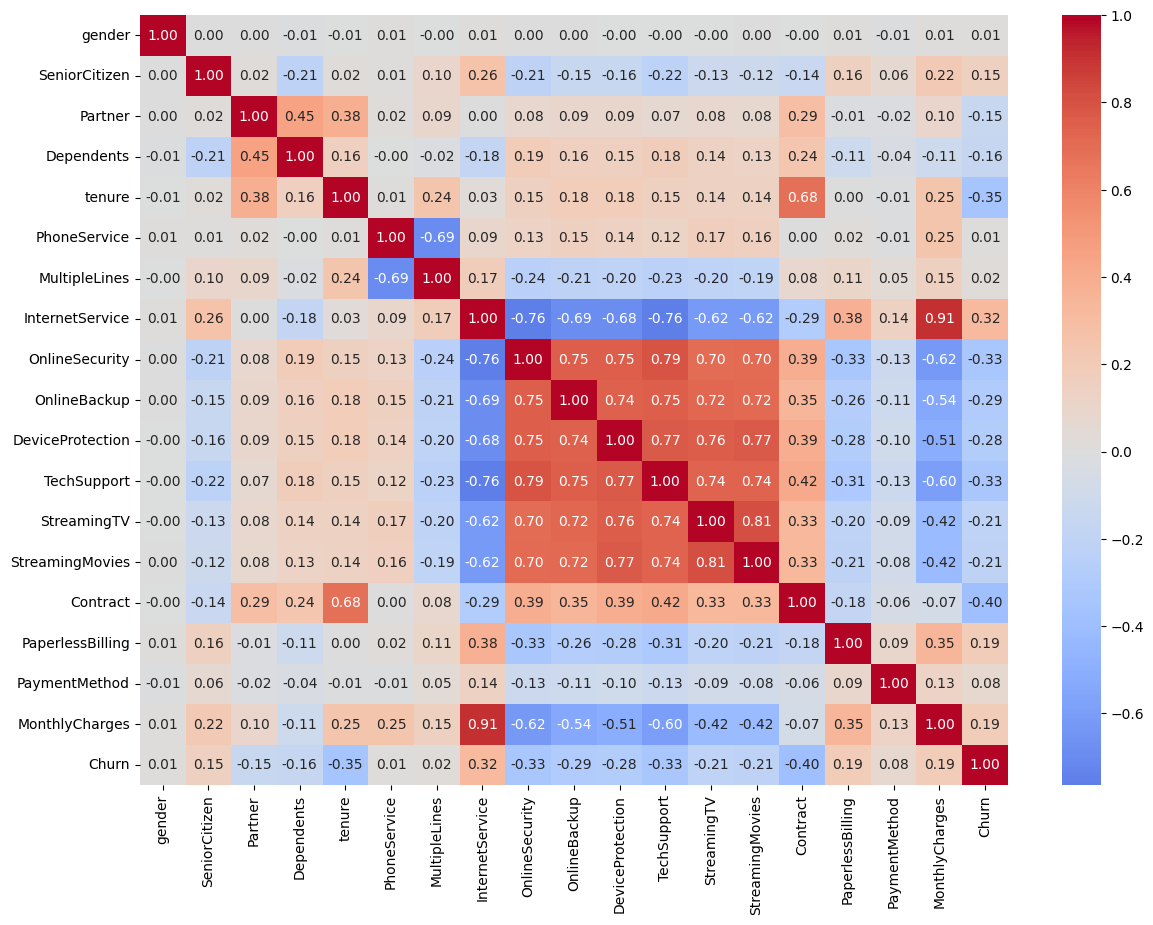

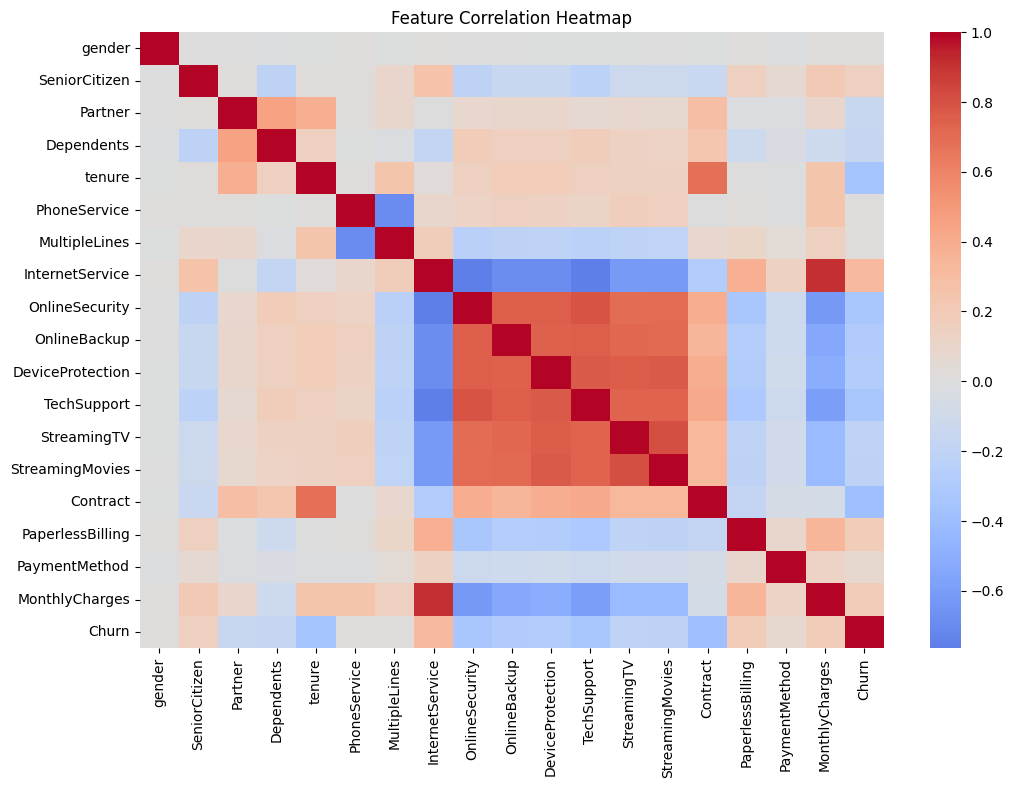

In [ ]:
print("Graphs showing Feature Engineering Before/After")
print(" ---------------------------------------------------")

import os
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

plt.close('all')

COLOR_BEFORE = "#3B82C4"
COLOR_AFTER = "#E0734C"

before_df = raw_df
after_df = df

#------------------------------------------
# Comparing loss of Rows Before/After
#------------------------------------------
rows_before_cleaning = len(before_df)
rows_after_cleaning = len(after_df)

print("Rows before:", len(raw_df))
print("Rows after:", len(df))
print("Rows removed:", len(raw_df) - len(df))

plt.figure(figsize=(5,5))
colums = ['BeforeCleaning', 'AfterCleaning']
values = [rows_before_cleaning, rows_after_cleaning]
plt.bar(colums, values, color=[COLOR_BEFORE, COLOR_AFTER])
plt.xlabel('Before and After')
plt.title('Rows Before and After Cleaning')
plt.ylabel('Values')
plt.show()

print("\n")
#--------------------------------------------
# Comparing changes of One-Hot Encoding
#--------------------------------------------

#Before Gender
plt.figure(figsize=(5,5))
before_df['gender'].value_counts().plot(kind='bar')
plt.title('Before Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()
#After Gender
plt.figure(figsize=(5,5))
after_df['gender'].value_counts().plot(kind='bar')
plt.title('After Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()
#Before Monthly Charges
plt.figure(figsize=(5,5))
before_df.boxplot(column='MonthlyCharges')
plt.title('Boxplot of Before Monthly Charges')
plt.ylabel('Values')
plt.show()
#After Monthly Charges
plt.figure(figsize=(5,5))
after_df.boxplot(column='MonthlyCharges')
plt.title('Boxplot of After Monthly Charges')
plt.ylabel('Values')
plt.show()

print("\n")
#--------------------------------------------
# Comparing Correlation, between features and to Churn itself
#--------------------------------------------

# Correlation Heatmap
plt.figure(figsize=(14,10))
correlation_matrix = after_df.corr()
#Heatmap with numbers
sns.heatmap(
    correlation_matrix,
    annot=True,      # Show correlation values
    fmt=".2f",       # Display 2 decimal places
    cmap="coolwarm",
    center=0
)
#Heatmap without numbers
plt.figure(figsize=(12,8))
sns.heatmap(
    after_df.corr(),
    cmap="coolwarm",
    center=0
)
plt.title("Feature Correlation Heatmap")
plt.show()



# Splitting Data / Testing Models

In [ ]:
#Start with Spliting, then go into SMOTE, then applying to models
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)
#Create cross validation split in dataset
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

def cross_validate_smote(model, X_train, y_train, cv):
    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        X_smote, y_smote = smote.fit_resample(X_fold_train, y_fold_train)

        model.fit(X_smote, y_smote)
        predictions = model.predict(X_fold_val)

        scores.append(f1_score(y_fold_val, predictions))

    return sum(scores) / len(scores)

########################################
# Linear Regression
########################################

model = LogisticRegression(max_iter=1000)
scores = cross_val_score(
    model,
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring='f1'
)
print("Average F1:", cross_validate_smote(model, X_train, y_train, cv))
#Train final model
model.fit(X_train_smote, y_train_smote)
predictions = model.predict(X_test)
#Print evaluations
print("\nLinear Regression Results")
print("---------------------")
print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall:", recall_score(y_test, predictions))
print("F1 Score:", f1_score(y_test, predictions))
print(confusion_matrix(y_test, predictions))

########################################
# Decision Tree
########################################

model = DecisionTreeClassifier(random_state=42)
scores = cross_val_score(
    model,
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring='f1'
)
print("Average F1:", cross_validate_smote(model, X_train, y_train, cv))
#Train final model
model.fit(X_train_smote, y_train_smote)
predictions = model.predict(X_test)
#Print evaluations
print("\nDecision Tree Results")
print("---------------------")
print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall:", recall_score(y_test, predictions))
print("F1 Score:", f1_score(y_test, predictions))
print(confusion_matrix(y_test, predictions))

########################################
# Random Forest
########################################
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
scores = cross_val_score(
    model,
    X_train_smote,
    y_train_smote,
    cv=cv,
    scoring='f1'
)
print("Average F1:", cross_validate_smote(model, X_train, y_train, cv))
model.fit(X_train_smote, y_train_smote)
predictions = model.predict(X_test)
print("\nRandom Forest Results")
print("---------------------")
print("Accuracy:", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions))
print("Recall:", recall_score(y_test, predictions))
print("F1 Score:", f1_score(y_test, predictions))
print(confusion_matrix(y_test, predictions))

Average F1: 0.6161634077381621

Linear Regression Results
---------------------
Accuracy: 0.7256574271499645
Precision: 0.4896907216494845
Recall: 0.7620320855614974
F1 Score: 0.5962343096234309
[[736 297]
 [ 89 285]]
Average F1: 0.5224666724412464

Decision Tree Results
---------------------
Accuracy: 0.7142857142857143
Precision: 0.4683257918552036
Recall: 0.553475935828877
F1 Score: 0.5073529411764706
[[798 235]
 [167 207]]
Average F1: 0.595383804972634

Random Forest Results
---------------------
Accuracy: 0.7469793887704336
Precision: 0.5209302325581395
Recall: 0.5989304812834224
F1 Score: 0.5572139303482587
[[827 206]
 [150 224]]
